# Comparison against stochastic gradient Markov chain Monte Carlo

**Authors:**  
- Thomas Goodwin (University of Technology Sydney)
- Matias Quiroz (University of Technology Sydney)

**Last changed:** 2026-05-09

**Description:**  
This notebook contains the code used to generate the stochastic gradient Markov chain Monte Carlo (SG-MCMC) results reported in the paper. The `sgmcmc_ssm` package is available at `https://github.com/aicherc/sgmcmc_ssm_code`. We applied minor modifications to ensure compatibility with our system. The changes required for a system with the following versions are detailed below:
-   Python: 3.12.3
-   NumPy: 2.0.2.
-   Pandas: 2.3.3.

This notebook contains the code required to reproduce the stochastic gradient Markov chain Monte Carlo (SG-MCMC) example presented in the paper "Stabilised weighted data subsampling for accelerated inference in models with recursive likelihoods" by Quiroz et al. (2026). The SG-MCMC methodology is developed in Aicher et al. (2025), and we use it to estimate a GARCH(1,1) model with noise and compare the results to those obtained from a subsampling Markov chain Monte Carlo algorithm (Quiroz et al., 2019), which incorporates our stabilised weighted subsampling approach for models with recursive likelihoods.

The code is organised as follows:

- **Section 1** imports the relevant modules and defines auxiliary functions.
- **Section 2** contains the GARCH(1,1) example used for comparison against SG-MCMC in the paper.
- **Section 3** outlines the modifications applied to the original package available at `https://github.com/aicherc/sgmcmc_ssm_code`.

**References**

Aicher, C., Putcha, S., Nemeth, C., Fearnhead, P and Fox, E. (2025). Stochastic gradient MCMC for nonlinear state space models. Bayesian Analysis, 20(1), 83-105.

Quiroz, M., Bhaskaran, A.,  Wang Z. and Goodwin, T. (2026). Stabilised weighted data subsampling for accelerated inference in models with recursive likelihoods. Manuscript in preparation.

Quiroz, M., Kohn, R., Villani, M., & Tran, M. N. (2019). Speeding Up MCMC by Efficient Data Subsampling. Journal of the American Statistical Association, 114(526), 831–843.



In [1]:
import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import seaborn as sns
from pathlib import Path
from time import time
from sgmcmc_ssm.trace_metric_functions import IMQ_KSD
from sgmcmc_ssm.models.garch import (
       generate_garch_data,
       GARCHParameters,
       GARCHPrior,
       GARCHHelper,
       GARCHSampler,
       )
from tqdm import tqdm
np.random.seed(12345)

## 1. Functions

Auxiliary functions.

In [2]:
def make_sgmcmc_garch_data_from_npz(
    file_path,
    omega,
    alpha1,
    beta1,
    tau2,
):
    """
    This function takes our simulated data and constructs objects for the sgmcmc code.
    """
    with np.load(file_path) as f:
        y = f["y"].copy()
        x = f["x"].copy()
        sigma2 = f["sigma2"].copy()

    if y.ndim != 1 or x.ndim != 1 or sigma2.ndim != 1:
        raise ValueError("y, x, and sigma2 must be 1D arrays.")
    if not (len(y) == len(x) == len(sigma2)):
        raise ValueError("y, x, and sigma2 must have the same length.")
    if len(y) < 2:
        raise ValueError("Need at least t=0 and t=1.")

    y0 = float(y[0])
    sigma2_0 = float(sigma2[0])

    if sigma2_0 <= 0:
        raise ValueError("sigma2_0 must be positive.")

    log_mu, logit_phi, logit_lambduh = GARCHParameters.convert_alpha_beta_gamma(
        alpha=omega,
        beta=alpha1,
        gamma=beta1,
    )

    parameters = GARCHParameters(
        log_mu=np.array([log_mu]),
        logit_phi=np.array([logit_phi]),
        logit_lambduh=np.array([logit_lambduh]),
        R=np.array([[tau2]]),
    )

    initial_message = {
        "log_constant": 0.0,
        "mean_precision": np.array([y0 / sigma2_0], dtype=float),
        "precision": np.array([[1.0 / sigma2_0]], dtype=float),
    }

    data = {
        "observations": y[1:].reshape(-1, 1),
        "latent_vars": x[1:].reshape(-1, 1),
        "sigma2s": sigma2[1:].copy(),
        "parameters": parameters,
        "initial_message": initial_message,
    }

    return data

def plot_kde_comparison_SG_MCMC(
    full_data_samples,
    subsampling_samples,
    sg_samples_list,
    sg_labels=None,
    param_names=[r"$\omega$", r"$\alpha_1$", r"$\beta_1$"],
    title="Posterior marginals: KDE comparison",
    n_points=200,
    true_vals=None,
    bw_method="scott",
    bw_adjust=1.0,
    figsize=(14.5, 4.2),
    x_pad_frac=0.02,          # smaller padding gives shorter x-limits
    tick_fontsize=15,         # bigger tick labels
    label_fontsize=18,
    legend_fontsize=12,
    legend_y=1.03,            # move legend closer to plots
    suptitle_y=1.08,          # title position
    xlims=None,               # optional manual x-limits, e.g. [(0.058,0.082), ...]
):

    # Convert inputs
    def _ensure_2d(arr):
        arr = np.asarray(arr, dtype=float)
        return arr[:, None] if arr.ndim == 1 else arr

    full_data_samples = _ensure_2d(full_data_samples)
    subsampling_samples = _ensure_2d(subsampling_samples)
    sg_samples_list = [_ensure_2d(s) for s in sg_samples_list]

    d = 3

    # Basic checks
    for arr in [full_data_samples, subsampling_samples] + sg_samples_list:
        if arr.shape[1] != d:
            raise ValueError("All sample sets must have exactly 3 parameters.")

    # Default SG labels
    if sg_labels is None:
        sg_labels = [f"SG-MCMC {i+1}" for i in range(len(sg_samples_list))]

    # Same colour for all SG methods, different line styles
    sg_color = "#E69F00"
    sg_linestyles = ["-", "--", "-.", ":"]
    sg_alphas = [0.95, 0.90, 0.85, 0.80]
    sg_linewidths = [2.0, 2.0, 2.0, 2.0]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = axes.ravel()

    for j in range(d):

        ax = axes[j]

        # Collect all samples for range
        x_list = (
            [full_data_samples[:, j], subsampling_samples[:, j]]
            + [s[:, j] for s in sg_samples_list]
        )
        x_all = np.concatenate(x_list)

        if xlims is not None:
            x_min, x_max = xlims[j]
        else:
            x_min, x_max = np.min(x_all), np.max(x_all)
            pad = x_pad_frac * (x_max - x_min if x_max > x_min else 1.0)
            x_min, x_max = x_min - pad, x_max + pad

        x_grid = np.linspace(x_min, x_max, n_points)

        # === Full-data (black) ===
        kde = sps.gaussian_kde(full_data_samples[:, j], bw_method=bw_method)
        if bw_adjust != 1.0:
            kde.set_bandwidth(kde.factor * bw_adjust)
        ax.plot(
            x_grid, kde(x_grid),
            color="black", lw=2.6, ls="-",
            label="Full-data MCMC", zorder=5
        )

        # === Subsampling (blue dashed) ===
        kde = sps.gaussian_kde(subsampling_samples[:, j], bw_method=bw_method)
        if bw_adjust != 1.0:
            kde.set_bandwidth(kde.factor * bw_adjust)
        ax.plot(
            x_grid, kde(x_grid),
            color="#0072B2", lw=2.2, ls="--",
            label="Subsampling MCMC", zorder=4
        )

        # === SG-MCMC (same colour, different styles) ===
        for k, s in enumerate(sg_samples_list):
            kde = sps.gaussian_kde(s[:, j], bw_method=bw_method)
            if bw_adjust != 1.0:
                kde.set_bandwidth(kde.factor * bw_adjust)

            ax.plot(
                x_grid, kde(x_grid),
                color=sg_color,
                lw=sg_linewidths[k % len(sg_linewidths)],
                ls=sg_linestyles[k % len(sg_linestyles)],
                alpha=sg_alphas[k % len(sg_alphas)],
                label=sg_labels[k],
                zorder=2,
            )

        if true_vals is not None:
            ax.axvline(true_vals[j], color="k", linestyle=":", linewidth=1.2)

        ax.set_xlim(x_min, x_max)
        ax.set_xlabel(param_names[j], fontsize=label_fontsize)
        ax.set_yticks([])
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis="x", labelsize=tick_fontsize, length=6, width=1.0)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Legend: reorder so Subsampling first, then SG-MCMC, then Full-data last   
    handles, labels = axes[0].get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_labels = ["Subsampling MCMC"] + sg_labels + ["Full-data MCMC"]
    ordered_handles = [label_to_handle[lbl] for lbl in ordered_labels]

    fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, legend_y),
        frameon=False,
        fontsize=legend_fontsize,
    )

    fig.suptitle(title, fontsize=14, y=suptitle_y)

    # tighter top margin so legend is closer to panels
    plt.tight_layout(rect=[0.03, 0.06, 0.97, 0.84])

    return fig, axes


def make_garch_parameters_from_draw(draw):
    """
    Convert draw = (omega, alpha1, beta1, tau)
    to the internal sgmcmc_ssm GARCHParameters object.
    """
    omega, alpha1, beta1, tau = draw

    log_mu, logit_phi, logit_lambduh = GARCHParameters.convert_alpha_beta_gamma(
        alpha=omega,
        beta=alpha1,
        gamma=beta1,
    )

    return GARCHParameters(
        log_mu=np.array([log_mu]),
        logit_phi=np.array([logit_phi]),
        logit_lambduh=np.array([logit_lambduh]),
        R=np.array([[tau**2]]),
    )


def parameter_vector_for_ksd(parameters):
    """
    Coordinates used for KSD. These must match the gradient coordinates.
    """
    return np.array([
        parameters.log_mu.item(),
        parameters.logit_phi.item(),
        parameters.logit_lambduh.item(),
        parameters.tau.item(),
    ])


def convert_gradient_for_ksd(gradient, parameters):
    """
    Convert their gradient dictionary to the same 4-vector as parameter_vector_for_ksd.
    """
    return np.array([
        gradient["log_mu"].item(),
        gradient["logit_phi"].item(),
        gradient["logit_lambduh"].item(),
        (gradient["LRinv_vec"] * (-(parameters.LRinv.item())**(-2))).item(),
    ])


def compute_ksd_for_draws(
    draws,
    sampler,
    n_eval=500,
    random_seed=123,
    N_score=10000,
    subsequence_length_score=1000,
    buffer_length_score=10,
    pf="poyiadjis_N",
):
    """
    Compute Aicher et al. IMQ KSD for draws stored as:
        (omega, alpha1, beta1, tau)

    The posterior score is estimated using their particle-filter score estimator.
    """

    rng = np.random.default_rng(random_seed)
    np.random.seed(random_seed)
    
    draws = np.asarray(draws, dtype=float)

    if draws.shape[0] > n_eval:
        idx = rng.choice(draws.shape[0], size=n_eval, replace=False)
        draws_eval = draws[idx]
    else:
        draws_eval = draws

    x_ksd = []
    grad_ksd = []

    for draw in tqdm(draws_eval, desc="Computing KSD score estimates"):
        parameters = make_garch_parameters_from_draw(draw)

        sampler.parameters = parameters

        grad = sampler.noisy_gradient(
            kind="pf",
            pf=pf,
            N=N_score,
            subsequence_length=subsequence_length_score,
            buffer_length=buffer_length_score,
            is_scaled=False,
        )

        x_ksd.append(parameter_vector_for_ksd(parameters))
        grad_ksd.append(convert_gradient_for_ksd(grad, parameters))

    x_ksd = np.asarray(x_ksd)
    grad_ksd = np.asarray(grad_ksd)

    ksd = IMQ_KSD(
        x_ksd,
        grad_ksd,
        c=1,
        beta=0.5,
        max_block_size=512,
    )

    return {
        "ksd": ksd,
        "log10_ksd": np.log10(ksd),
        "n_eval": x_ksd.shape[0],
        "x_ksd": x_ksd,
        "grad_ksd": grad_ksd,
    }

## 2. Application in the supplement: Comparison against stochastic gradient Markov chain Monte Carlo

This section provides the code used to compare subsampling Markov chain Monte Carlo (Quiroz et al., 2019), based on our stabilised weighted subsampling approach (Quiroz et al., 2026), with stochastic gradient Markov chain Monte Carlo (SG-MCMC) for nonlinear state space models, as proposed in Aicher et al. (2025). The code estimates the model using the authors’ package and stores the corresponding results.

The results are presented in the companion notebook, `stabilised_weighted_data_subsampling.ipynb`, which also generates the figures and tables included in the supplement.

In this empirical application, we fit a GARCH($1,1$) model with normal errors to simulated data. The simulation parameters are calibrated to match those obtained from fitting the model to the Dow Jones Industrial Average in the main paper.

Note that Aicher et al. (2025) use a different parameterisation than Quiroz et al. (2026) and, moreover, consider a GARCH-with-noise state space formulation. The correspondence between the two formulations is summarised in the table below; see Section S4.1 in the supplement of the paper for a detailed reconciliation of the models.

| Quantity                          | Quiroz et al. (2026)      | Aicher et al. (2025)        |
|----------------------------------|---------------------------|-----------------------------|
| Mean                             | $\mu$                     | $0$                         |
| GARCH constant                   | $\omega$                  | $\alpha$                    |
| Lagged squared term              | $\alpha_1$                | $\beta$                     |
| Lagged variance term             | $\beta_1$                 | $\gamma$                    |
| Conditional variance of $y_t$    | $\sigma_t^2$              | $\sigma_t^2 + \tau^2$       |
| Unconditional variance of $y_t$ ($E(\sigma_t^2)$) | $\omega / (1 - \alpha_1 - \beta_1)$ | $\alpha / (1 - \beta - \gamma)$ |
| Persistence                      | $\alpha_1 + \beta_1$      | $\beta + \gamma$            |

In [3]:
# MAP estimates (from full-data run on data generated with tau2 = 1%)
omega = 7.49189562e-02
alpha1 = 1.58559442e-01
beta1 = 7.85863559e-01 

# True values in the simulation (calibrated from Dow Jones industrial data)
omega_true = 0.07134079
alpha1_true = 0.16151262
beta1_true = 0.78591371


Esigma2 = omega / (1.0 - alpha1 - beta1)
tau2_0p01pct = 0.0001 * Esigma2


data_dir = Path("data")

# Create data/parameters. Note: Data simulated using tau2 corresponding to 0.01% of the Esigma2
data_tau = make_sgmcmc_garch_data_from_npz(
    data_dir / "garch_tau2_0p01pct.npz",
    omega=omega,
    alpha1=alpha1,
    beta1=beta1,
    tau2=tau2_0p01pct,
)


In [4]:
# construct GARCH SGMCMC sampler starting at true values
parameters = data_tau["parameters"]
prior = GARCHPrior.generate_default_prior(**parameters.dim, var=1)

## Access Prior Parameters
print(prior.hyperparams)

sampler = GARCHSampler(**parameters.dim, parameters = parameters)
sampler.setup(data_tau["observations"], prior,  parameters = parameters)
print("Starting parameters:", sampler.parameters, sep = "\n")


{'scale_mu': 3, 'shape_mu': 4, 'alpha_phi': 20.0, 'beta_phi': 2.2222222222222223, 'alpha_lambduh': 20.0, 'beta_lambduh': 2.2222222222222223, 'scale_Rinv': array([[0.33333333]]), 'df_Rinv': 3.0}
Starting parameters:
GARCHParameters:
alpha:0.074919, beta:0.158559, gamma:0.785864, tau:0.01161



In [5]:
# Settings
niter = 12000
print_every = 100

N = 1000 # Nbr of particles
epsilon_list = [1, 0.1, 0.01, 0.001] 
subsequence_length = 40
buffer_length = 10

# Paths
SG_dir = Path("results/SG_runs")
SG_dir.mkdir(parents=True, exist_ok=True)

for run_nbr, epsilon in enumerate(epsilon_list):
    # Loop over settings
    print(f"Running SG-MCMC with epsilon = {epsilon}.")
    setting_nbr = run_nbr

    save_path_SG = SG_dir / f"sgmcmc_tau2_0p01pct_niter{niter}_setting{setting_nbr}.npz"

    try:
        # ===================== LOAD =====================
        with np.load(save_path_SG, allow_pickle=True) as f:
            sgmcmc_draws = f["sgmcmc_draws"]
            settings = f["settings"].item()
            timing = f["timing"].item()
            start_value = f["start_value"]

        print(f"Loaded SG-MCMC results from {save_path_SG}")

    except FileNotFoundError:

        # ===================== RUN =====================
        sgmcmc_draws = np.zeros((niter, 4))

        sgmcmc_draws[0] = np.r_[
            sampler.parameters.alpha,
            sampler.parameters.beta,
            sampler.parameters.gamma,
            sampler.parameters.tau.flatten(),
        ]

        start_value = sgmcmc_draws[0].copy()

        sampling_time = 0.0
        t0 = time()

        for i in range(1, niter):

            t_step = time()
            sampler.sample_sgld(
                kind='pf',
                N=N,
                epsilon=epsilon,
                subsequence_length=subsequence_length,
                buffer_length=buffer_length,
            )
            sampling_time += time() - t_step

            sgmcmc_draws[i] = np.r_[
                sampler.parameters.alpha,
                sampler.parameters.beta,
                sampler.parameters.gamma,
                sampler.parameters.tau.flatten(),
            ]

            if (i + 1) % print_every == 0:
                print(
                    f"Iteration: {i+1} / {niter}  "
                    f"Total elapsed: {time()-t0:.3f}s  "
                    f"Sampling only: {sampling_time:.3f}s"
                )

        total_elapsed = time() - t0

        print(f"\nTotal elapsed time: {total_elapsed:.3f}s")
        print(f"Sampling-only time: {sampling_time:.3f}s")

        # ===================== SAVE =====================
        settings = {
            "niter": niter,
            "kind": "pf",
            "N": N,
            "epsilon": epsilon,
            "subsequence_length": subsequence_length,
            "buffer_length": buffer_length,
        }

        timing = {
            "total_elapsed": total_elapsed,
            "sampling_only": sampling_time,
            "overhead": total_elapsed - sampling_time,
            "avg_total_per_iter": total_elapsed / (niter - 1),
            "avg_sampling_per_iter": sampling_time / (niter - 1),
        }

        np.savez(
            save_path_SG,
            sgmcmc_draws=sgmcmc_draws,
            settings=np.array(settings, dtype=object),
            timing=np.array(timing, dtype=object),
            start_value=start_value,
        )

        print(f"Saved SG-MCMC results to {save_path_SG}")

Running SG-MCMC with epsilon = 1.
Loaded SG-MCMC results from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting0.npz
Running SG-MCMC with epsilon = 0.1.
Loaded SG-MCMC results from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting1.npz
Running SG-MCMC with epsilon = 0.01.
Loaded SG-MCMC results from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting2.npz
Running SG-MCMC with epsilon = 0.001.
Loaded SG-MCMC results from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting3.npz


Read in SG-results stored above and full-data result. Do kernel density estimates comparison against SG-MCMC.

Loaded epsilon=1 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting0.npz
Loaded epsilon=0.1 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting1.npz
Loaded epsilon=0.01 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting2.npz
Loaded epsilon=0.001 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting3.npz


(<Figure size 1450x420 with 3 Axes>,
 array([<Axes: xlabel='$\\omega$'>, <Axes: xlabel='$\\alpha_1$'>,
        <Axes: xlabel='$\\beta_1$'>], dtype=object))

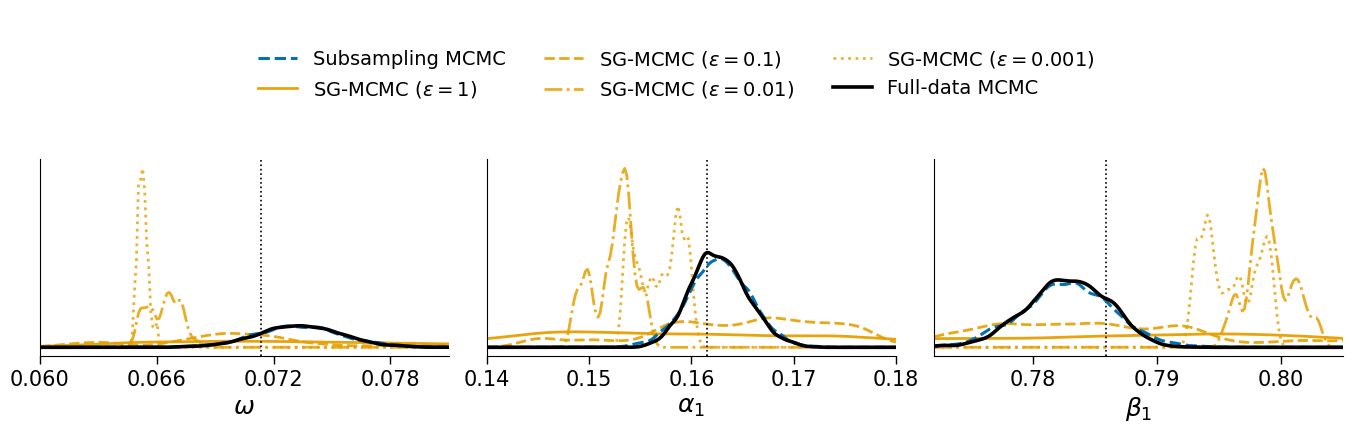

In [8]:
# Collect SG-MCMC
burn_in = 2000
thin = 1

SG_results = []

for setting_nbr, epsilon in enumerate(epsilon_list):
    file_path = SG_dir / f"sgmcmc_tau2_0p01pct_niter{niter}_setting{setting_nbr}.npz"

    with np.load(file_path, allow_pickle=True) as f:
        result = {
            "draws": f["sgmcmc_draws"],
            "settings": f["settings"].item(),
            "timing": f["timing"].item(),
            "start_value": f["start_value"],
        }

    SG_results.append(result)

    print(f"Loaded epsilon={epsilon} from {file_path}")


sg_samples_list = [SG_results[item]['draws'][burn_in::thin, [0, 1, 2]] for item in range(len(epsilon_list))]

# Full data run
res = np.load("full_data_run_tau2_0p01.npz", allow_pickle=True)
result_full_data_MCMC = res["arr_0"].item()

# subsampling MCMC run
res2 = np.load("subsampling_run_tau2_0p01.npz", allow_pickle=True)
subsampling_MCMC = res2["arr_0"].item()


xlims = [
    (0.060, 0.081),   # omega
    (0.140, 0.18),   # alpha_1
    (0.772, 0.805),   # beta_1
]

# Plot KDEs
plot_kde_comparison_SG_MCMC(
    result_full_data_MCMC["samples_theta"][(burn_in + 1)::thin, [1, 2, 3]],
    subsampling_MCMC["samples_theta"][(burn_in + 1)::thin, [1, 2, 3]],
    sg_samples_list,
    sg_labels= [r"SG-MCMC $(\varepsilon = 1)$", r"SG-MCMC $(\varepsilon = 0.1)$", r"SG-MCMC $(\varepsilon = 0.01)$", r"SG-MCMC $(\varepsilon = 0.001)$"],
    param_names=[r"$\omega$", r"$\alpha_1$", r"$\beta_1$"],
    title=" ",
    n_points=200,
    true_vals=np.array([omega_true, alpha1_true, beta1_true]),
    bw_method="scott",
    bw_adjust=1.0,
    legend_fontsize=14,
    xlims=xlims
)

In [15]:
# =========================================================
# KSD settings several repetitions
# =========================================================
KSD_dir = Path("results/SG_runs")
KSD_dir.mkdir(parents=True, exist_ok=True)

n_rep_ksd = 6
base_seed = 12345
ksd_seeds = [base_seed + r for r in range(n_rep_ksd)]

burn_in = 2000
thin = 20
n_eval_ksd = 500
N_score_ksd = 10000
subsequence_length_score_ksd = 1000
buffer_length_score_ksd = 10

tau_fixed = np.sqrt(tau2_0p01pct)

save_path_ksd = (
    KSD_dir
    / f"ksd_tau2_0p01pct_neval{n_eval_ksd}_Nscore{N_score_ksd}"
      f"_Sscore{subsequence_length_score_ksd}_Bscore{buffer_length_score_ksd}"
      f"_nrep{n_rep_ksd}.npz"
)

try:
    # ===================== LOAD =====================
    with np.load(save_path_ksd, allow_pickle=True) as f:
        ksd_df = pd.DataFrame(f["ksd_summary"].tolist())
        ksd_all = f["ksd_all"].tolist()
        settings_ksd = f["settings_ksd"].item()

    print(f"Loaded KSD results from {save_path_ksd}")

except FileNotFoundError:

    print("No saved KSD results found. Computing KSDs...")

    # -------------------------------------------------
    # Prepare draws (same as your original)
    # -------------------------------------------------
    sg_draws_for_ksd_list = [
        SG_results[k]["draws"][burn_in::thin, :]
        for k in range(len(epsilon_list))
    ]

    full_theta = result_full_data_MCMC["samples_theta"][
        (burn_in + 1)::thin, [1, 2, 3]
    ]
    full_draws_for_ksd = np.column_stack([
        full_theta,
        np.full(full_theta.shape[0], tau_fixed),
    ])

    sub_theta = subsampling_MCMC["samples_theta"][
        (burn_in + 1)::thin, [1, 2, 3]
    ]
    sub_draws_for_ksd = np.column_stack([
        sub_theta,
        np.full(sub_theta.shape[0], tau_fixed),
    ])

    # -------------------------------------------------
    # Assert equal lengths
    # -------------------------------------------------
    lengths = (
        [d.shape[0] for d in sg_draws_for_ksd_list]
        + [full_draws_for_ksd.shape[0], sub_draws_for_ksd.shape[0]]
    )

    assert len(set(lengths)) == 1, f"Mismatch in lengths: {lengths}"
    assert lengths[0] >= n_eval_ksd, "Not enough samples"

    print(f"All methods have {lengths[0]} draws")

    # -------------------------------------------------
    # Storage
    # -------------------------------------------------
    methods = (
        [rf"SG-MCMC epsilon={eps}" for eps in epsilon_list]
        + ["Full-data MCMC", "Subsampling MCMC"]
    )

    ksd_all = {m: [] for m in methods}
    # =================================================
    # KSD repetitions
    # =================================================
    for r, seed in enumerate(ksd_seeds):

        print(f"\n========== KSD repetition {r+1}/{n_rep_ksd} (seed={seed}) ==========")

        # SG-MCMC
        for k, epsilon in enumerate(epsilon_list):
            print(f"Computing SG-MCMC (epsilon={epsilon})")

            out = compute_ksd_for_draws(
                sg_draws_for_ksd_list[k],
                sampler=sampler,
                n_eval=n_eval_ksd,
                random_seed=seed,
                N_score=N_score_ksd,
                subsequence_length_score=subsequence_length_score_ksd,
                buffer_length_score=buffer_length_score_ksd,
            )
            ksd_all[rf"SG-MCMC epsilon={epsilon}"].append(out["log10_ksd"])

        # Full-data
        print("Computing Full-data MCMC")

        out_full = compute_ksd_for_draws(
            full_draws_for_ksd,
            sampler=sampler,
            n_eval=n_eval_ksd,
            random_seed=seed,
            N_score=N_score_ksd,
            subsequence_length_score=subsequence_length_score_ksd,
            buffer_length_score=buffer_length_score_ksd,
        )
        ksd_all["Full-data MCMC"].append(out_full["log10_ksd"])

        # Subsampling
        print("Computing Subsampling MCMC")

        out_sub = compute_ksd_for_draws(
            sub_draws_for_ksd,
            sampler=sampler,
            n_eval=n_eval_ksd,
            random_seed=seed,
            N_score=N_score_ksd,
            subsequence_length_score=subsequence_length_score_ksd,
            buffer_length_score=buffer_length_score_ksd,
        )
        ksd_all["Subsampling MCMC"].append(out_sub["log10_ksd"])



    # =================================================
    # Summary table
    # =================================================
    ksd_summary = []

    for m in methods:
        vals = np.array(ksd_all[m])
        ksd_summary.append({
            "method": m,
            "log10_ksd_mean": vals.mean(),
            "log10_ksd_sd": vals.std(),
            "log10_ksd_min": vals.min(),
            "log10_ksd_max": vals.max(),
        })

    ksd_df = pd.DataFrame(ksd_summary).sort_values("log10_ksd_mean")

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    settings_ksd = {
        "n_rep": n_rep_ksd,
        "seeds": ksd_seeds,
        "n_eval": n_eval_ksd,
        "N_score": N_score_ksd,
        "subsequence_length_score": subsequence_length_score_ksd,
        "buffer_length_score": buffer_length_score_ksd,
    }

    np.savez(
        save_path_ksd,
        ksd_summary=np.array(ksd_summary, dtype=object),
        ksd_all=np.array(ksd_all, dtype=object),
        settings_ksd=np.array(settings_ksd, dtype=object),
    )

    print(f"Saved KSD results to {save_path_ksd}")

ksd_df

Loaded KSD results from results/SG_runs/ksd_tau2_0p01pct_neval500_Nscore10000_Sscore1000_Bscore10_nrep6.npz


,method,log10_ksd_mean,log10_ksd_sd,log10_ksd_min,log10_ksd_max
0,SG-MCMC epsilon=1,1.618778,0.102722,1.521329,1.784148
1,SG-MCMC epsilon=0.1,1.513227,0.137316,1.340452,1.722266
2,SG-MCMC epsilon=0.01,1.950111,0.054224,1.881702,2.023741
3,SG-MCMC epsilon=0.001,1.738130,0.081233,1.616374,1.840538
4,Full-data MCMC,1.054792,0.280094,0.534195,1.397570
5,Subsampling MCMC,1.089792,0.226712,0.653762,1.358797


In [14]:
ksd_df

,method,log10_ksd_mean,log10_ksd_sd,log10_ksd_min,log10_ksd_max
4,Full-data MCMC,1.054792,0.280094,0.534195,1.397570
5,Subsampling MCMC,1.089792,0.226712,0.653762,1.358797
1,SG-MCMC epsilon=0.1,1.513227,0.137316,1.340452,1.722266
0,SG-MCMC epsilon=1,1.618778,0.102722,1.521329,1.784148
3,SG-MCMC epsilon=0.001,1.738130,0.081233,1.616374,1.840538
2,SG-MCMC epsilon=0.01,1.950111,0.054224,1.881702,2.023741


Load to disk so it can be read from `stabilised_weighted_data_subsampling.ipynb`.

In [16]:
save_dir = Path("results/SG_runs/KSD_tables")
save_dir.mkdir(parents=True, exist_ok=True) 

save_path = save_dir / "ksd_summary_tau2_0p01pct.npz"

np.savez(
    save_path,
    ksd_df=ksd_df.to_dict(orient="records"),  # robust for DataFrame
)

print(f"Saved KSD table to {save_path}")

Saved KSD table to results/SG_runs/KSD_tables/ksd_summary_tau2_0p01pct.npz


## 3. Modifications to the `sgmcmc_ssm` code required

Make the following changes to the downloaded code (download from `https://github.com/aicherc/sgmcmc_ssm_code`):

- In the file `sgmcmc_ssm_code/sgmcmc_ssm/models/garch/parameters.py`, replace:
  - `np.asscalar(self.alpha)` with `self.alpha.item()` (line 33)
  - `np.asscalar(self.beta)` with `self.beta.item()` (line 34)
  - `np.asscalar(self.gamma)` with `self.gamma.item()` (line 35)
  - `np.asscalar(self.tau)` with `self.tau.item()` (line 36)

  Note that these changes affect the `__str__` method, which is only used for printing objects, so no executable code is modified.

- In the file `sgmcmc_ssm_code/sgmcmc_ssm/base_parameters.py`, replace:
  - `np.asscalar(logprior)` with `logprior.item()` (line 174)